In [76]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [77]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [7]:
len(x_train)

60000

In [8]:
len(x_test)

    

10000

In [9]:
x_train.shape

(60000, 28, 28)

In [10]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

0 means it is black 
255,254.. white to black as well as value decreases white will turn to black

In [82]:
x_train_flattened = x_train.reshape(len(x_train), 28*28) / 255
x_test_flattened = x_test.reshape(len(x_test), 28*28) / 255

In [100]:
model = keras.Sequential([
    keras.layers.Dense(
        10,
        input_shape=(784,),
        activation='softmax'
    )
])

c:\Users\mdima\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [102]:
model.fit(
    x_train_flattened,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 860us/step - accuracy: 0.8792 - loss: 0.4664
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step - accuracy: 0.9156 - loss: 0.3035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 898us/step - accuracy: 0.9205 - loss: 0.2829
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 867us/step - accuracy: 0.9241 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 867us/step - accuracy: 0.9255 - loss: 0.2666


In [103]:
y_pred = model.predict(x_test_flattened)

print("Actual:", y_test[0])
print("Predicted:", np.argmax(y_pred[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step
Actual: 7
Predicted: 7


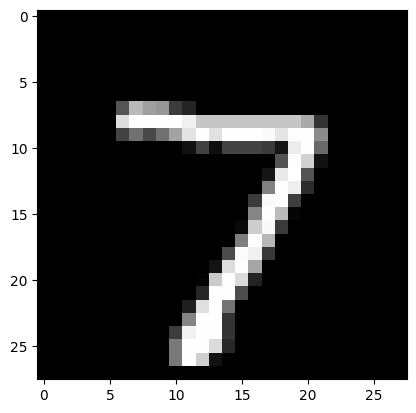

In [104]:
plt.imshow(x_test[0], cmap='gray')
plt.show()

In [105]:
y_pred_labels = [np.argmax(i) for i in y_pred]
y_pred_labels[:5]

[7, 2, 1, 0, 4]

In [106]:
y_test = y_test[:5]
y_test

array([7, 2, 1, 0, 4], dtype=uint8)

In [107]:
import tensorflow as tf
# y_test was reduced to 5 samples earlier, so keep the same number of predictions
y_pred_subset = y_pred_labels[:len(y_test)]

cm = tf.math.confusion_matrix(
    labels=y_test,
    predictions=y_pred_subset
)
cm


<tf.Tensor: shape=(8, 8), dtype=int32, numpy=
array([[1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1]])>

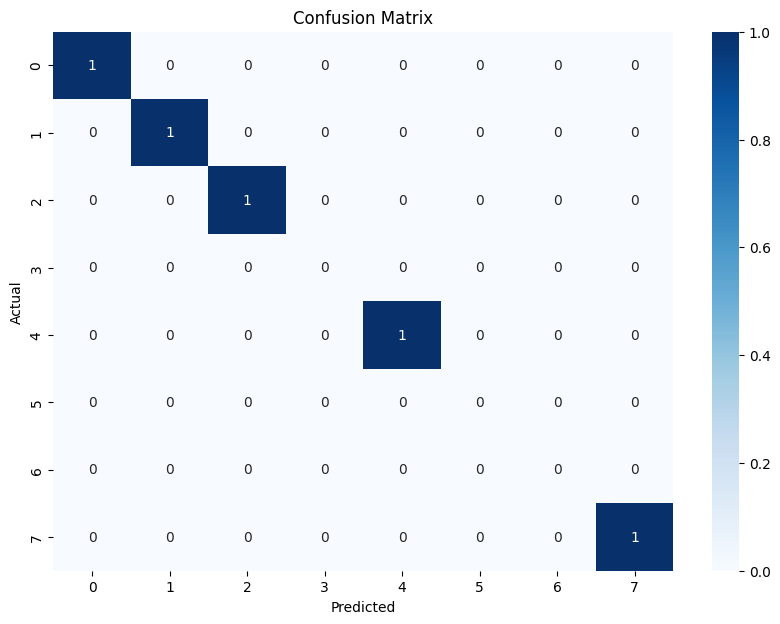

In [108]:
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [113]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='softmax')

])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(x_train_flattened,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9239 - loss: 0.2680
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9639 - loss: 0.1217
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9744 - loss: 0.0859
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.9800 - loss: 0.0652
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9845 - loss: 0.0506


In [ ]:

_, (_, y_test_full) = a

model.evaluate(x_test_flattened, y_test_full)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9782 - loss: 0.0733


[0.07325473427772522, 0.9782000184059143]

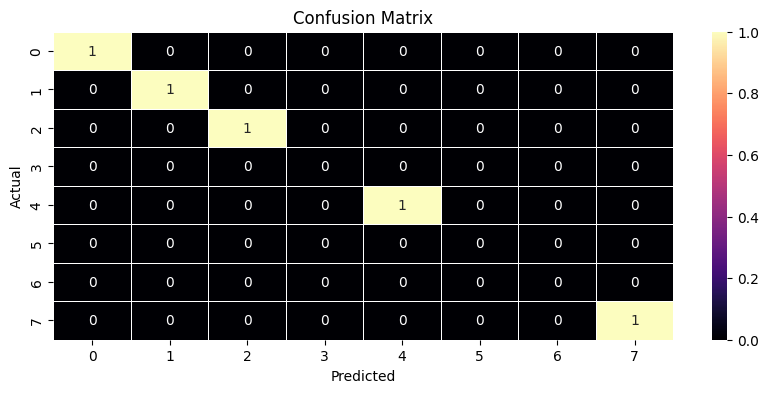

In [119]:
plt.figure(figsize=(10, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    linewidths=0.5
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()